## Compare reported-case predictions across normalization and gene target settings

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd


def set_fontsize(base_fontsize=15):
    fontsize = base_fontsize
    plt.rcParams.update({
        'font.size': fontsize,
        'axes.titlesize': fontsize,
        'axes.labelsize': fontsize,
        'xtick.labelsize': fontsize * 0.8,
        'ytick.labelsize': fontsize * 0.8,
        'legend.fontsize': fontsize * 0.8,
        'font.family': 'Arial',
    })


plt.style.use('default')
set_fontsize()

ROOT = Path('/home/iru-mls/marvin/ww_bonn_jax')
phase_cut_date = '2023-03-15'
objective = 'cases_and_conc'
cutoff_value = 0.05

result_paths = {
    ('flow', 'N1'): ROOT / '2_results_initial_submission' / 'Bonn',
    ('flow', 'N2'): ROOT / 'Bonn_flow_N2',
    ('flow', 'N1_N2'): ROOT / 'Bonn_flow_N1_N2',
    ('PMMoV', 'N1'): ROOT / 'Bonn_PMMoV_N1',
    ('PMMoV', 'N2'): ROOT / 'Bonn_PMMoV_N2',
    ('PMMoV', 'N1_N2'): ROOT / 'Bonn_PMMoV_N1_N2',
}

normalization_order = ['flow', 'PMMoV']
target_order = ['N1', 'N2', 'N1_N2']

path_table = pd.DataFrame(
    [
        {
            'normalization': normalization,
            'gene_target': gene_target,
            'result_path': str(result_paths[(normalization, gene_target)]),
        }
        for normalization in normalization_order
        for gene_target in target_order
    ]
)
path_table


,normalization,gene_target,result_path
0,flow,N1,/home/iru-mls/marvin/ww_bonn_jax/2_results_ini...
1,flow,N2,/home/iru-mls/marvin/ww_bonn_jax/Bonn_flow_N2
2,flow,N1_N2,/home/iru-mls/marvin/ww_bonn_jax/Bonn_flow_N1_N2
3,PMMoV,N1,/home/iru-mls/marvin/ww_bonn_jax/Bonn_PMMoV_N1
4,PMMoV,N2,/home/iru-mls/marvin/ww_bonn_jax/Bonn_PMMoV_N2
5,PMMoV,N1_N2,/home/iru-mls/marvin/ww_bonn_jax/Bonn_PMMoV_N1_N2


In [2]:
import json
import sys

import matplotlib.dates as mdates
import numpy as np

if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from optimization import optimization_utils


def build_base_config(substance_normalization, gene_target):
    return {
        'data_kwargs': {
            'town': 'Bonn',
            'sampling_area': 'North_South',
            'project': 'both',
            'max_precipitation_subsetting': None,
            'substance_normalization': substance_normalization,
            'gene_target': gene_target,
            'log_scale': True,
        },
        'E0': 862.857,
        'I0': 1294.286,
        'R0': 162092.04,
        'phase_cut_date': phase_cut_date,
        'dt': 0.2,
        'underreporting_model': 'monotone_increasing',
    }


def load_experiment_bundle(substance_normalization, gene_target):
    result_root = result_paths[(substance_normalization, gene_target)]
    visualization_dir = (
        result_root
        / 'multistart_results'
        / f'{phase_cut_date}_{objective}'
        / f'visualizations_{cutoff_value}'
    )
    hparams_path = result_root / f'optuna_best_{phase_cut_date}_{objective}' / 'hparams.json'

    if not visualization_dir.exists():
        raise FileNotFoundError(visualization_dir)
    if not hparams_path.exists():
        raise FileNotFoundError(hparams_path)

    with open(hparams_path) as f:
        hparams = json.load(f)

    config = build_base_config(substance_normalization, gene_target)
    config.update(hparams)
    data = optimization_utils.two_phase_integrative_model_load_data(config)

    return {
        'result_root': result_root,
        'visualization_dir': visualization_dir,
        'hparams': hparams,
        'data': data,
        'I_data': np.load(visualization_dir / 'ensemble_predictions_I7_reported.npz'),
    }


experiment_data = {
    (normalization, gene_target): load_experiment_bundle(normalization, gene_target)
    for normalization in normalization_order
    for gene_target in target_order
}


/tmp/ipykernel_113038/3325121581.py:113: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


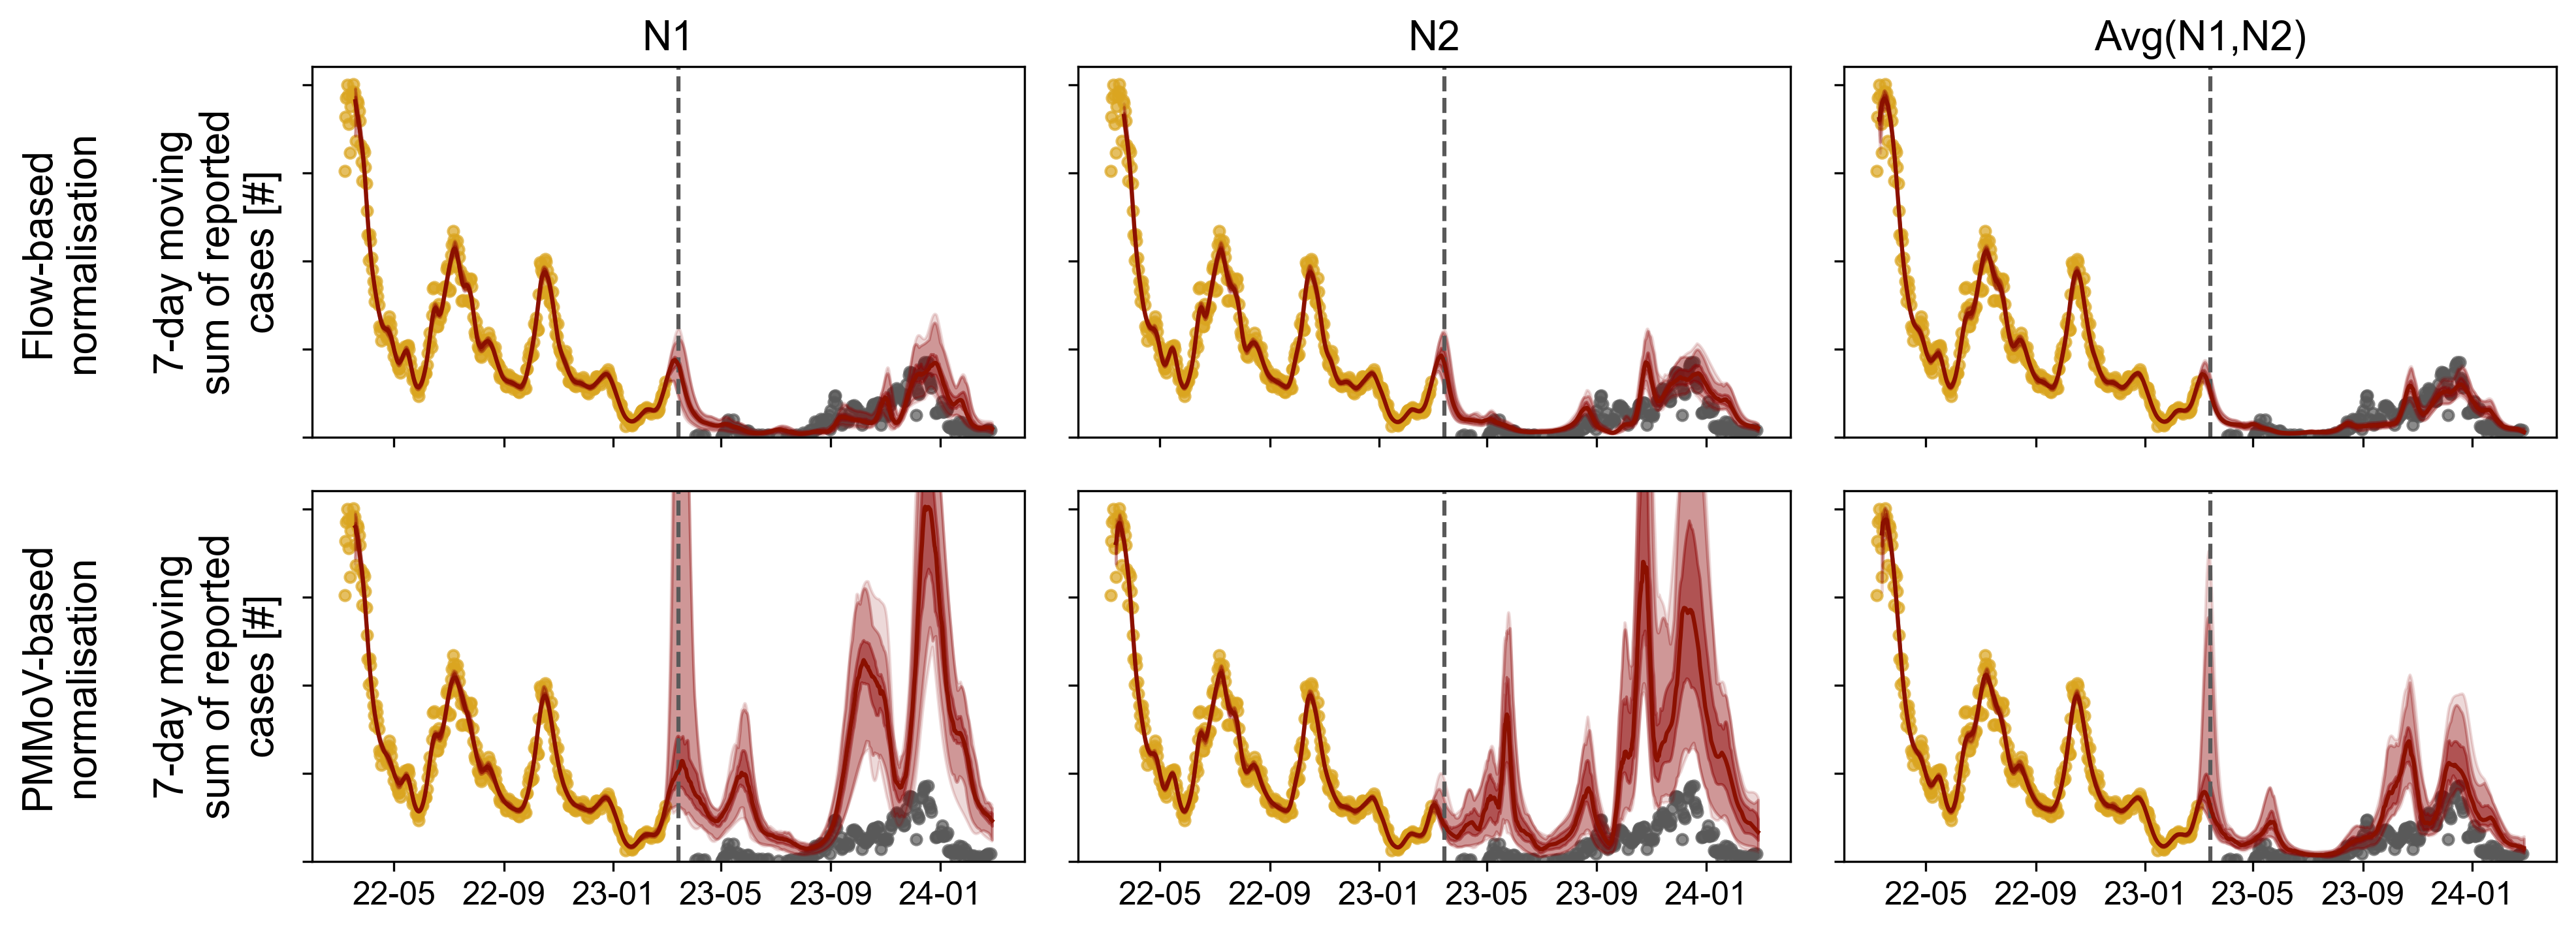

In [7]:
row_labels = {
    'flow': 'Flow-based\nnormalisation\n\n7-day moving\nsum of reported\ncases [#]',
    'PMMoV': 'PMMoV-based\nnormalisation\n\n7-day moving\nsum of reported\ncases [#]',
}

quantile_levels = [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975]

fig, axs = plt.subplots(
    nrows=2,
    ncols=3,
    sharex=True,
    sharey=True,
    figsize=(13.4, 5),
    dpi=300,
    constrained_layout=True,
)

for row, normalization in enumerate(normalization_order):
    for col, gene_target in enumerate(target_order):
        ax = axs[row, col]
        bundle = experiment_data[(normalization, gene_target)]
        data = bundle['data']
        quantiles_I = {
            q: np.quantile(bundle['I_data']['all'], q, axis=0)
            for q in quantile_levels
        }

        I7_median = quantiles_I[0.5]
        I7_low = quantiles_I[0.025]
        I7_high = quantiles_I[0.975]

        ax.scatter(
            data['I_dates_train'],
            data['I_train'],
            label='Training/validation\n(reported cases)',
            color='goldenrod',
            alpha=0.7,
            s=15,
        )
        ax.scatter(
            data['I_dates_val'],
            data['I_val'],
            label=None,
            color='goldenrod',
            alpha=0.7,
            s=15,
        )
        ax.scatter(
            data['obs_dates_phase_2'],
            data['I_test'],
            label='Test',
            color='#595959',
            alpha=0.7,
            s=15,
        )
        ax.axvline(
            pd.to_datetime(phase_cut_date),
            color='#595959',
            linestyle='--',
            label='Phase split',
        )

        ax.fill_between(
            data['dates_all'][1:],
            I7_low,
            I7_high,
            color='#8B0000',
            alpha=0.15,
            label='95% CI',
        )
        I7_low = quantiles_I[0.05]
        I7_high = quantiles_I[0.95]
        ax.fill_between(
            data['dates_all'][1:],
            I7_low,
            I7_high,
            color='#8B0000',
            alpha=0.3,
            label='90% CI',
        )
        I7_low = quantiles_I[0.25]
        I7_high = quantiles_I[0.75]
        ax.fill_between(
            data['dates_all'][1:],
            I7_low,
            I7_high,
            color='#8B0000',
            alpha=0.45,
            label='50% CI',
        )
        ax.plot(
            data['dates_all'][1:],
            I7_median,
            label='Median',
            color='#8B1000',
        )

        if row == 0:
            ax.set_title(gene_target)

        if col == 0:
            ax.set_ylabel(row_labels[normalization])
        elif col==2:
            if row==0:
                ax.set_title('Avg(N1,N2)')
        else:
            ax.set_yticklabels([])

        ax.set_ylim(bottom=0)
        ax.xaxis.set_major_locator(mdates.MonthLocator(bymonth=(1, 5, 9)))
        ax.xaxis.set_major_formatter(mdates.DateFormatter('%y-%m'))

plt.tight_layout()
plt.savefig('Bonn_normalization_gene_target_comparison.png', dpi=300, bbox_inches='tight')


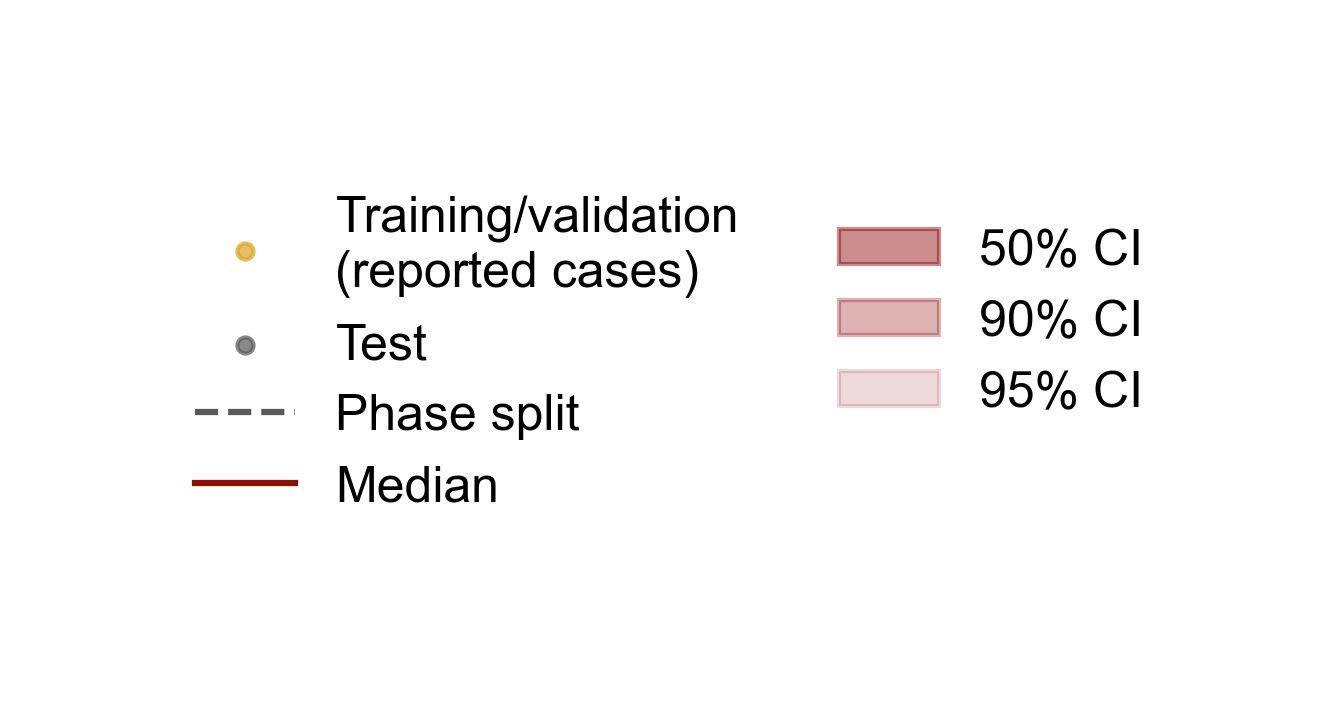

In [8]:
fig2, ax2 = plt.subplots(figsize=(5.5, 2.8), dpi=300)

handles_by_label = {}
for ax in axs.ravel():
    handles, labels = ax.get_legend_handles_labels()
    for handle, label in zip(handles, labels):
        if label and label not in handles_by_label:
            handles_by_label[label] = handle

legend_order = [
    'Training/validation\n(reported cases)',
    'Test',
    'Phase split',
    'Median',
    '50% CI',
    '90% CI',
    '95% CI',
]

ordered_labels = [label for label in legend_order if label in handles_by_label]
ordered_handles = [handles_by_label[label] for label in ordered_labels]

ax2.axis('off')
fig2.legend(ordered_handles, ordered_labels, frameon=False, ncol=2, loc='center')
fig2.savefig('Bonn_normalization_gene_target_comparison_legend.png', dpi=300, bbox_inches='tight')
